# 📝 Instrucciones: Construcción de Modelo de Regresión Lineal
Prediciendo la diabetes
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.



---

## Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

- Pregnancies. Número de embarazos del paciente (numérico)
- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- BMI. Índice de masa corporal (numérico)
- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
- Age. Edad del paciente (numérico)
- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)
---

## Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.
---

## Paso 3: Construye un modelo de árbol de decisión
Comienza a resolver el problema implementando un árbol de decisión y analiza cuál de los dos tipos satisface tus necesidades. Entrénalo y analiza sus resultados. Prueba a modificar la función de cálculo de la pureza de los nodos y utiliza todas las disponibles. Descríbelas y analiza sus resultados graficándolos.
---

## Paso 4: Optimiza el modelo
Después de entrenar el árbol con las distintas funciones de pureza, selecciona el mejor de ellos y optimiza sus hiperparámetros utilizando un grid search.

In [4]:
#importamos librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree #VISUALIZACION DE TRAIN DECISION TREE
import joblib

In [5]:
total_data = pd.read_csv('../data/raw/diabetes.csv')
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
total_data.shape

(768, 9)

In [7]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
total_data.select_dtypes(include=['object']).columns
num_cols = total_data.select_dtypes(include=["int64","float64"]).columns

In [9]:
total_data.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
print("PORCENTAJE DE VALORES NULOS DEL dataset\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': total_data.isna().sum() / len(total_data) * 100
}).sort_values(by='% Nullidad', ascending = False)
info_nulls

PORCENTAJE DE VALORES NULOS DEL dataset



,% Nullidad
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


In [11]:
print(total_data.isnull().sum())
print(f"La cantidad de valores nulos son {total_data.isnull().sum().sum()}")

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
La cantidad de valores nulos son 0


In [12]:
# Columnas donde el valor 0 es fisiológicamente imposible
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_invalid_cols:
    n_zeros = (total_data[col] == 0).sum()
    pct     = n_zeros / len(total_data) * 100
    print(f'{col:<25} {n_zeros:>8} {pct:>11.1f}%')
print('  Estos ceros serán sustituidos por NaN')

Glucose                          5         0.7%
BloodPressure                   35         4.6%
SkinThickness                  227        29.6%
Insulin                        374        48.7%
BMI                             11         1.4%
  Estos ceros serán sustituidos por NaN


In [13]:
total_data[zero_invalid_cols] = total_data[zero_invalid_cols].replace(0, np.nan)
for col in zero_invalid_cols:
    n_zeros = (total_data[col] == 0).sum()
    pct     = n_zeros / len(total_data) * 100
    print(f'{col:<25} {n_zeros:>8} {pct:>11.1f}%')
print('\n Los valores fueron sustituidos correctamente por Nan \n')
print(total_data.isnull().sum())

Glucose                          0         0.0%
BloodPressure                    0         0.0%
SkinThickness                    0         0.0%
Insulin                          0         0.0%
BMI                              0         0.0%

 Los valores fueron sustituidos correctamente por Nan 

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## Este data set incluye variables numéricas y no categorias, nuestra variable target es el outcome que esta en 1 y 0

## Este análisis preliminar permitió confirmar que la información está correctamente estructurada, no se aprecian valores atípicos ni valores nulos aunque es cierto que hay muchos valores a 0 que se han puesto a Nan.
nota: los valores en Nan seran cambiados por la media de cada columna


In [14]:
# Usamos la mediana de cada columna
total_data.fillna(total_data.median(), inplace = True)
total_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [15]:
total_data.describe(include = 'all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


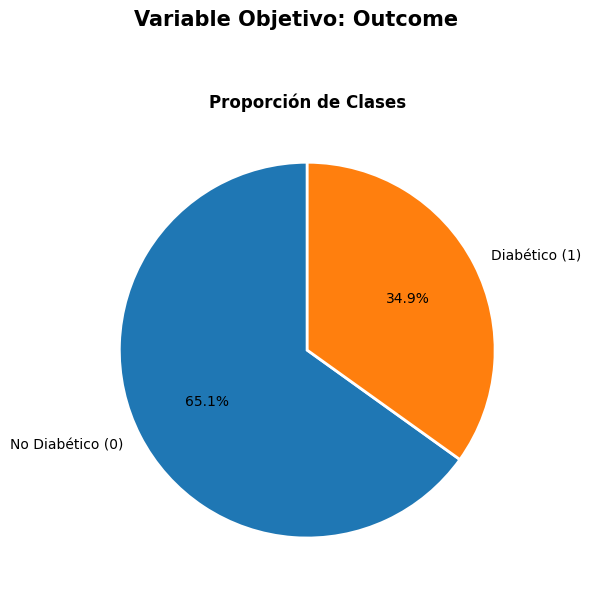

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

outcome_counts = total_data['Outcome'].value_counts()
outcome_pct    = total_data['Outcome'].value_counts(normalize=True) * 100

ax.pie(outcome_counts, labels=['No Diabético (0)', 'Diabético (1)'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Proporción de Clases', fontweight='bold')

plt.suptitle('Variable Objetivo: Outcome', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

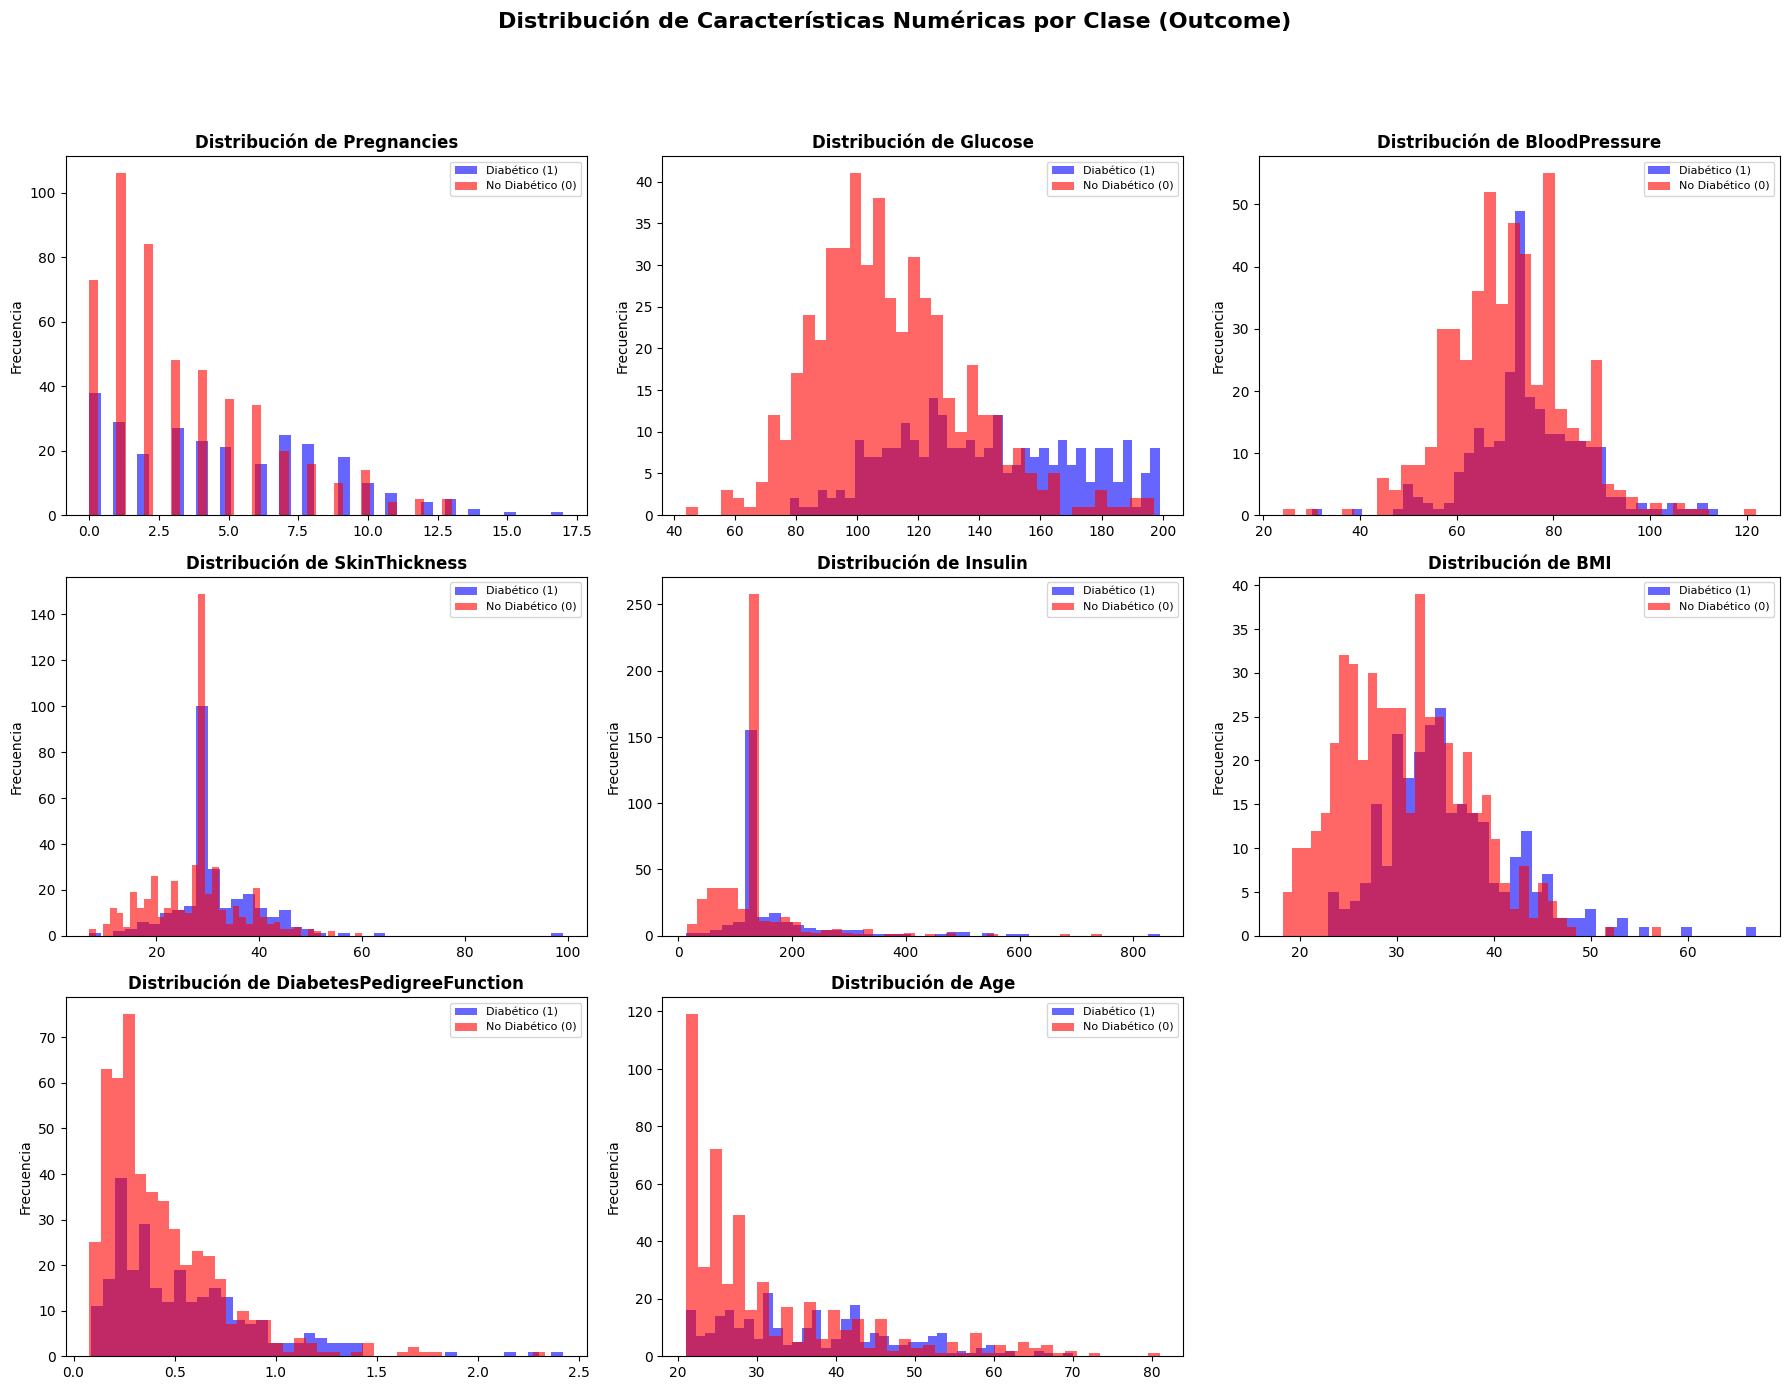

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.flatten()

features_to_plot = [col for col in num_cols if col != 'Outcome']

for i, col in enumerate(features_to_plot):
    if i < len(axes):
        total_data[total_data['Outcome'] == 1][col].plot(kind='hist', bins=40, ax=axes[i], alpha=0.6, label='Diabético (1)', color='blue')
        total_data[total_data['Outcome'] == 0][col].plot(kind='hist', bins=40, ax=axes[i], alpha=0.6, label='No Diabético (0)', color='red')
        axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_xlabel('') # Clear x-label to avoid clutter
        axes[i].set_ylabel('Frecuencia')

for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Características Numéricas por Clase (Outcome)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Las características Glucosa, BMI, Insulina, Edad y Pregnancies parecen tener el mayor poder predictivo, mostrando diferencias más claras en sus distribuciones entre los pacientes diabéticos y no diabéticos. Se aprecia que la edad se encuentra la mayoria en la poblacion joven

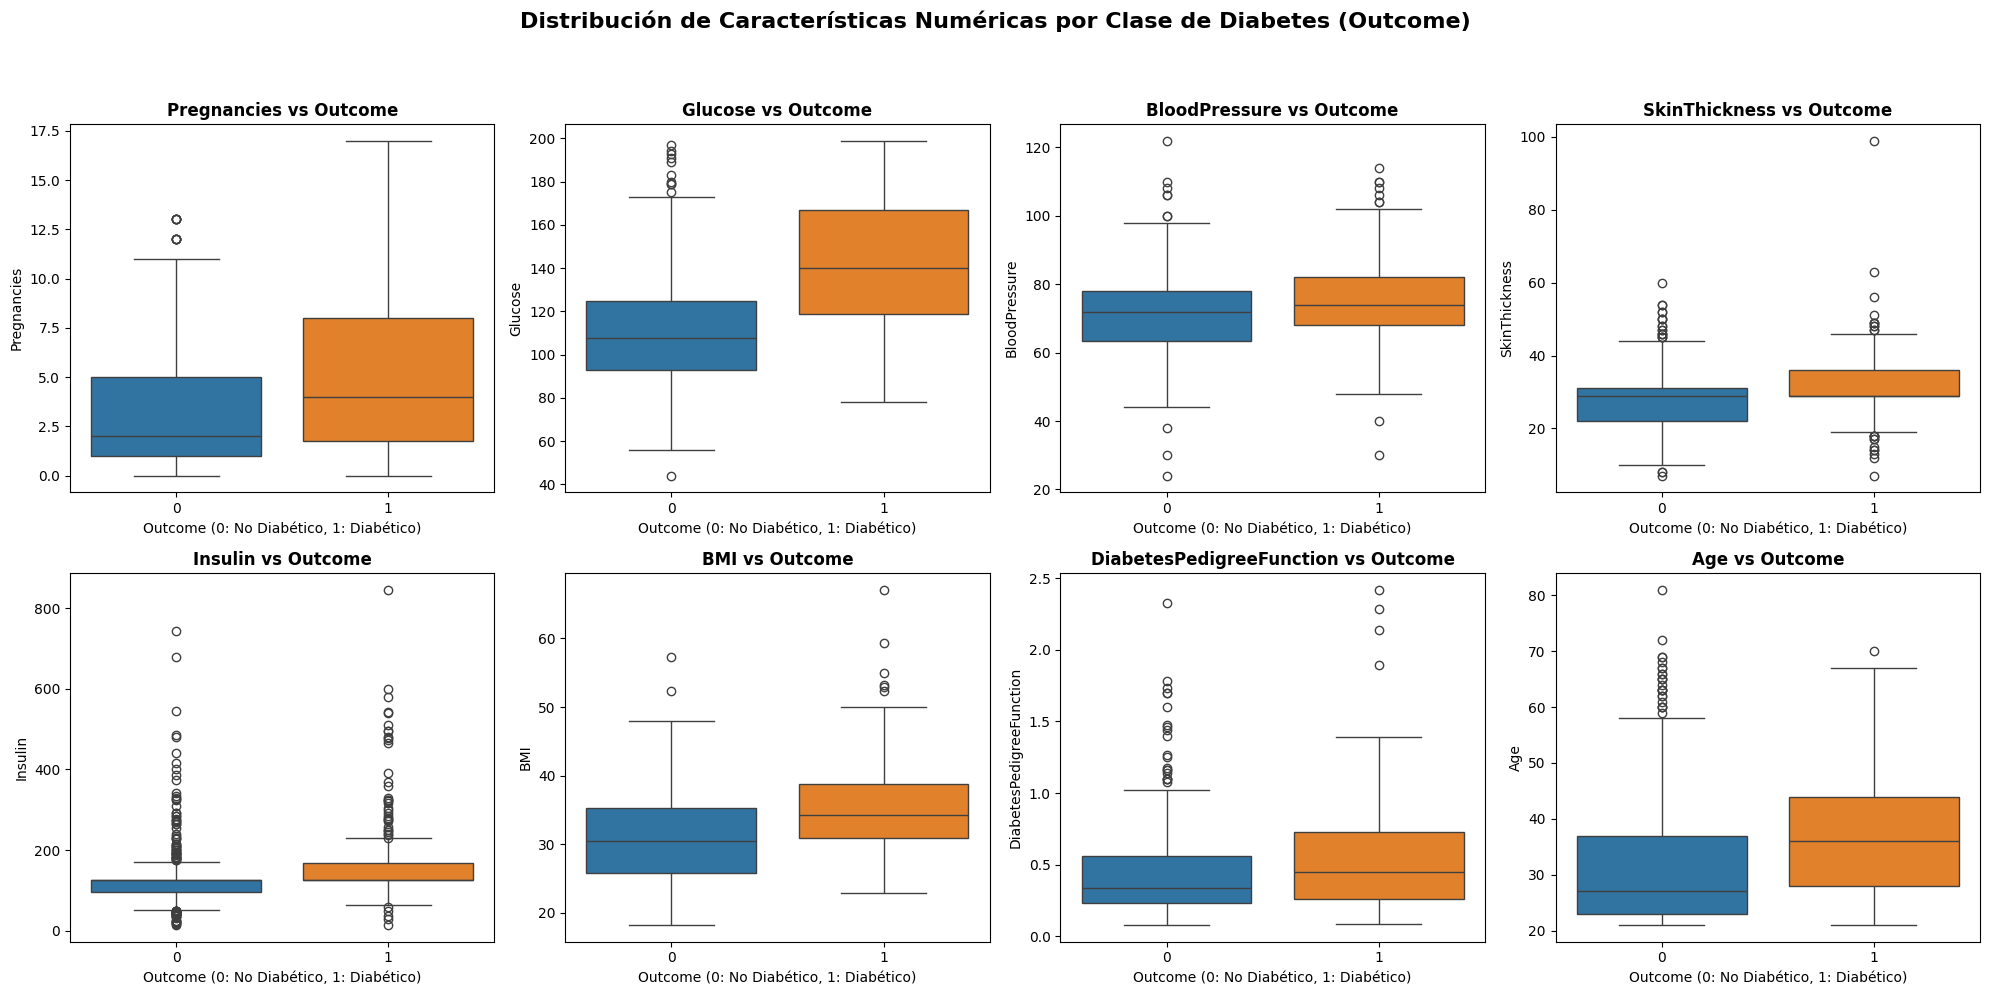

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

features_to_plot = [col for col in total_data.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']

for i, col in enumerate(features_to_plot):
    if i < len(axes):
        sns.boxplot(data=total_data, x='Outcome', y=col, ax=axes[i], hue='Outcome', legend=False)
        axes[i].set_title(f'{col} vs Outcome', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Outcome (0: No Diabético, 1: Diabético)')
        axes[i].set_ylabel(col)

plt.suptitle('Distribución de Características Numéricas por Clase de Diabetes (Outcome)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Glucosa, BMI, Insulina y Age muestran diferencias claras entre los grupos y son probablemente los predictores más importantes.

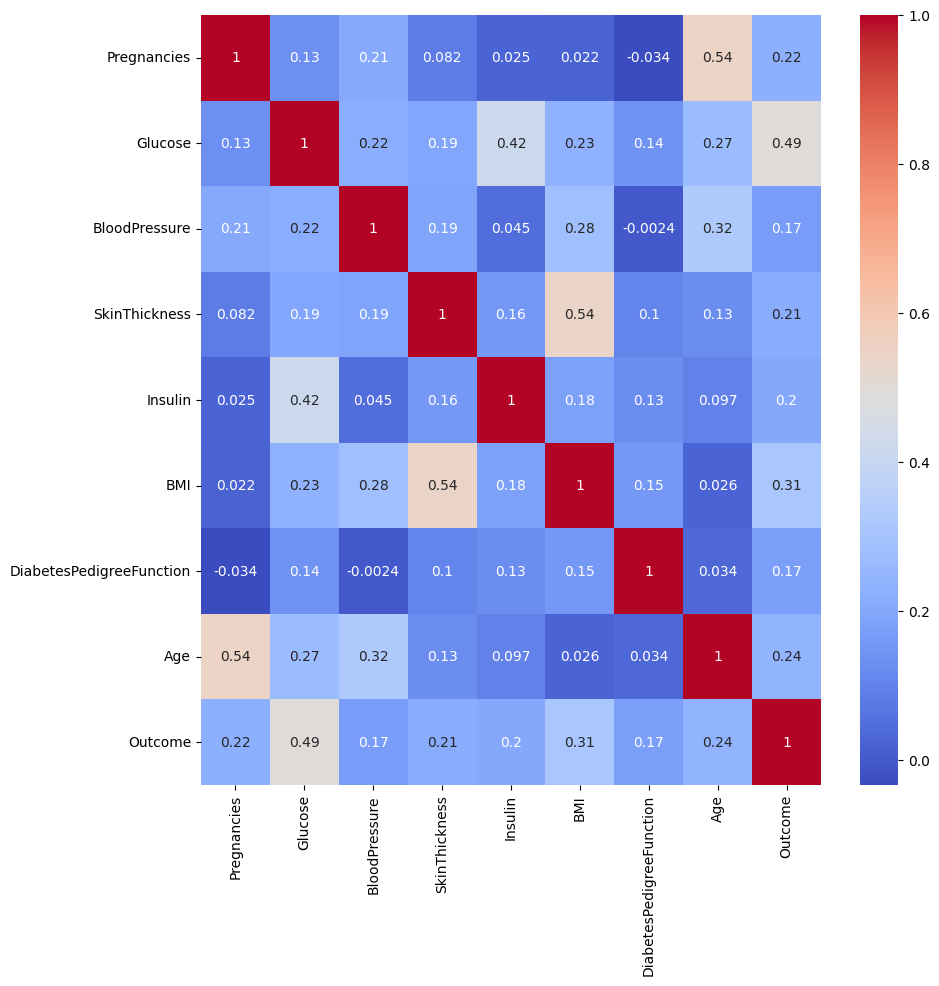

In [19]:
plt.figure(figsize= (10,10))
sns.heatmap(total_data.corr(), annot=True, cmap='coolwarm')
plt.show()

## La matriz de correlación nos muestra que la variable Glucose posee la mayor relación con la diabetes, seguida por BMI, Age y Pregnancies. Aunque todas las variables tienen muy buena correlacion por lo que nos pueden aportar información relevante para identificar la enfermedad.



# Preparamos el split

In [20]:
X = total_data.drop("Outcome", axis=1)
y = total_data["Outcome"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
X_train.to_csv("../data/processed/X_train_diabetes.csv", index=False)
X_test.to_csv("../data/processed/X_test_diabetes.csv", index=False)

y_train.to_csv("../data/processed/y_train_diabetes.csv", index=False)
y_test.to_csv("../data/processed/y_test_diabetes.csv", index=False)

# Aplicamos el modelo de decision tree

In [23]:

## se saco esto fe internet porque no estaba en las clases esta opcion
def evaluate_model(model, X_train, X_test, y_train, y_test, name=''):
    """Entrena y evalúa un modelo. Devuelve un dict con todas las métricas."""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    metrics = {
        'model':       name,
        'train_acc':   accuracy_score(y_train, y_train_pred),
        'test_acc':    accuracy_score(y_test,  y_test_pred),
        'precision':   precision_score(y_test, y_test_pred),
        'recall':      recall_score(y_test, y_test_pred),
        'f1':          f1_score(y_test, y_test_pred),
        'overfit_gap': accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
        'y_pred':      y_test_pred,
        'fitted_model': model
    }
    return metrics


# ── Entrenar los tres modelos ─────────────────────────────────────────────────
criteria = ['gini', 'entropy', 'log_loss']
results  = {}

for criterion in criteria:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    try:
        res = evaluate_model(model, X_train, X_test, y_train, y_test, name=criterion)
        results[criterion] = res
        print(f'✅ Modelo [{criterion:9}] entrenado  →  Test Accuracy: {res["test_acc"]:.4f}  |  F1: {res["f1"]:.4f}')
    except Exception as e:
        print(f'⚠️  Modelo [{criterion}] no disponible: {e}')



✅ Modelo [gini     ] entrenado  →  Test Accuracy: 0.6818  |  F1: 0.5149
✅ Modelo [entropy  ] entrenado  →  Test Accuracy: 0.6753  |  F1: 0.5283
✅ Modelo [log_loss ] entrenado  →  Test Accuracy: 0.6753  |  F1: 0.5283


In [24]:
decision_tree = DecisionTreeClassifier(random_state=42)

In [25]:
#ENTRENAMOS EL CLASIFICADOR
#Entrenamos o "ajustamos" el clasificador con los datos de entrenamiento
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [26]:
#Realizamos las predicciones sobre el conjunto de pruebas
y_pred = decision_tree.predict(X_test) #PREDICCIÓN DEL MODELO
print(y_pred)

[1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0]


In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6818181818181818

Confusion Matrix:
 [[79 21]
 [28 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



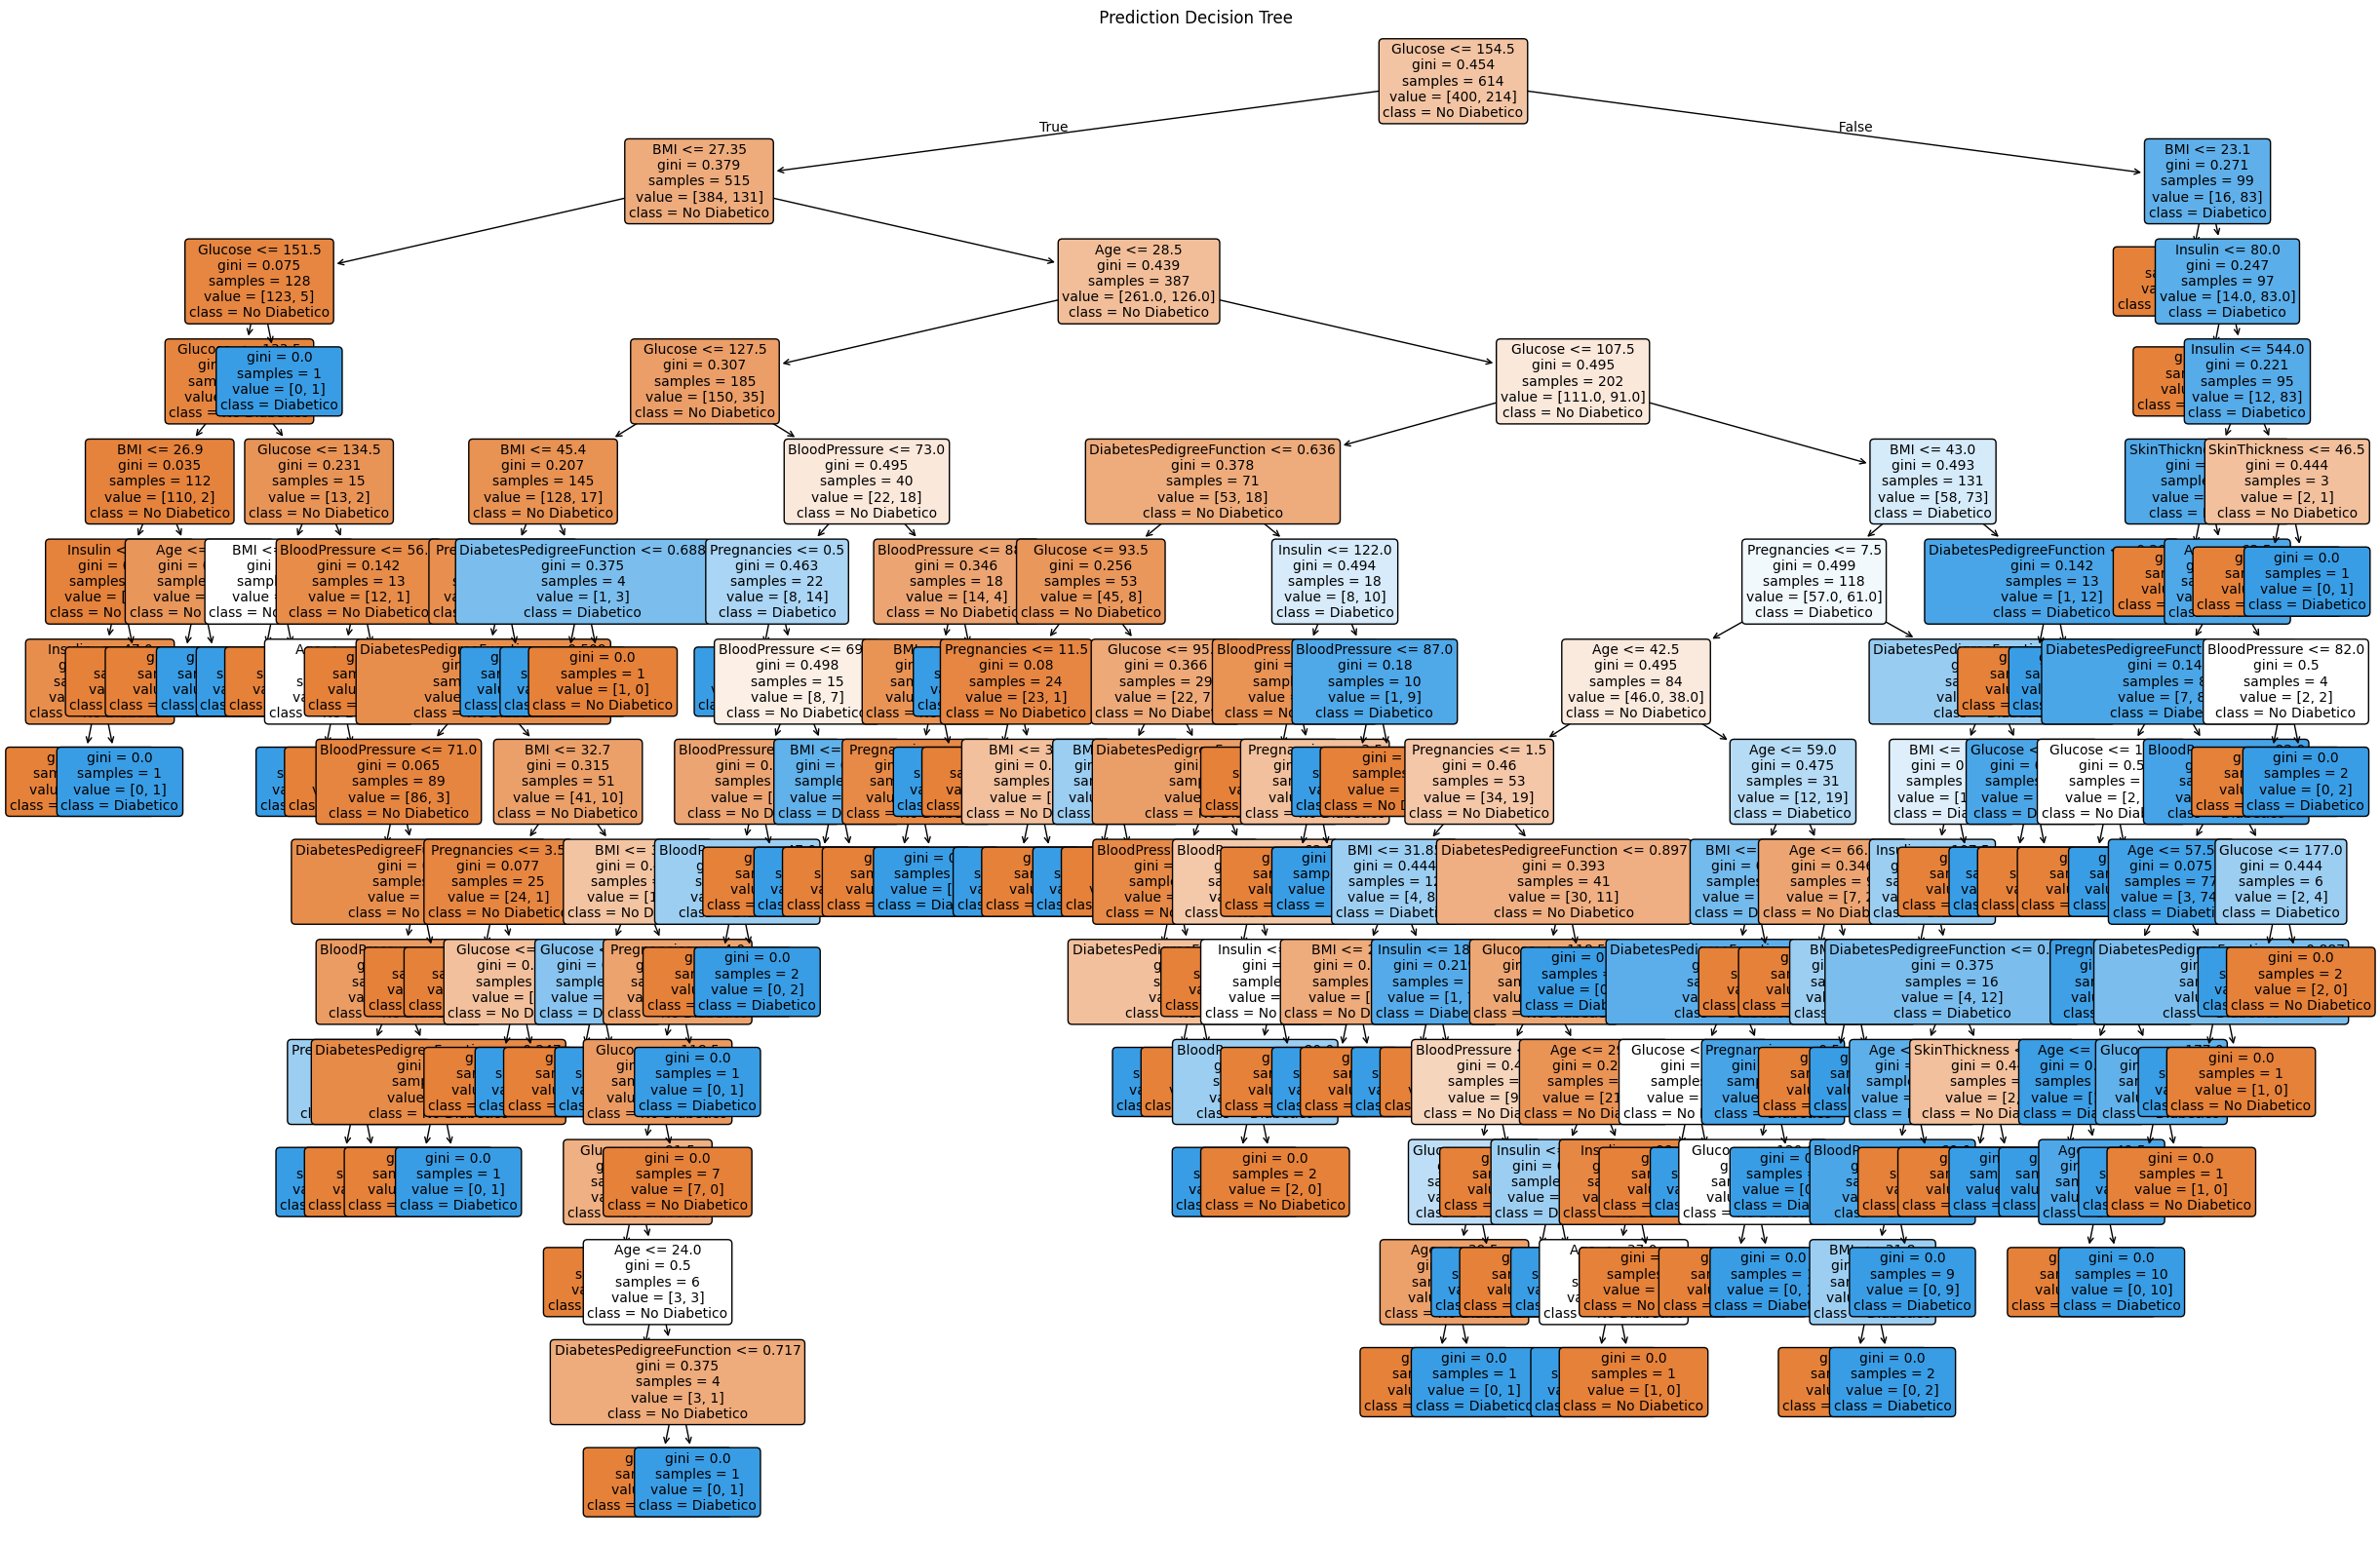

In [28]:
#VISUALICEMOS DECISION TREE
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 20))
plot_tree(decision_tree, feature_names=X_train.columns, class_names = ['No Diabetico', 'Diabetico'], filled=True, rounded=True, fontsize=10)
plt.title(" Prediction Decision Tree")
plt.show()

In [29]:
param = {
    "criterion" : ["gini", "entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" : [1,2,3,4,5,15,None],
    "max_features" : ["sqrt", "log2", None]
}

In [30]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [31]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [32]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 2,
 'max_features': None,
 'splitter': 'random'}

# Conclusiones:
- Glucose es la variable más correlacionada con la diabetes (0.47), seguida de BMI, Age y Pregnancies.
- La optimización con GridSearchCV redujo el sobreajuste significativamente, mejorando la capacidad de generalización del modelo.
-  Mejor criterio   : GINI
  {'criterion': 'gini',
 'max_depth': 2,
 'max_features': None,
 'splitter': 'random'}


Cargamos el modelo :

In [33]:
decision_tree = joblib.dump(decision_tree, "../models/decision_tree_model.pkl")